In [2]:
import matplotlib.pyplot as plt
import numpy as np

import archimedes as arc

Text(0.5, 1.0, 'Chirp Force Input')

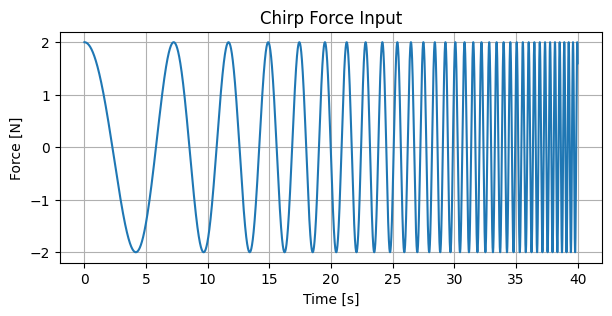

In [3]:
# Scipy chirp function for force

from scipy.signal import chirp

t0, tf = 0.0, 40.0
A = 2.0  # Forcing amplitude [N]
dt = 1e-3  # 1 kHz fine step for "truth"
tp = np.arange(t0, tf, dt)
u_chirp = A * chirp(tp, f0=0.1, f1=3.0, t1=tf, method='logarithmic')

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(tp, u_chirp)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Force [N]')
ax.grid()
ax.set_title('Chirp Force Input')

Text(0.5, 1.0, 'Test Force Input (Multi-sine)')

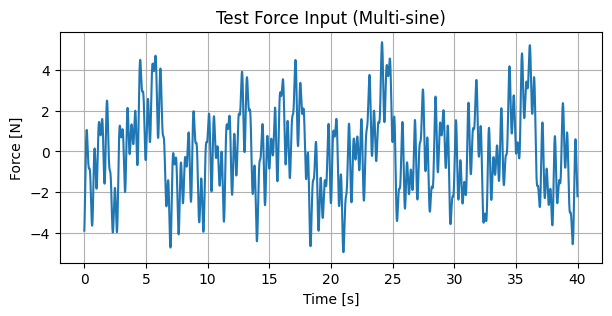

In [4]:
np.random.seed(42)
rng = np.random.default_rng(42)

freqs = np.logspace(np.log10(0.1), np.log10(3.0), 8)
phase = rng.uniform(0, 2 * np.pi, len(freqs))

u_test = np.sum(np.sin(2 * np.pi * freqs[:, None] * tp + phase[:, None]), axis=0)

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(tp, u_test)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Force [N]')
ax.grid()
ax.set_title('Test Force Input (Multi-sine)')

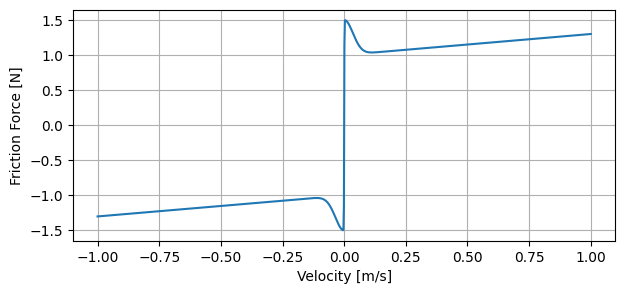

In [5]:
# Spring-mass-friction model

# Spring and mass parameters (assumed known/measurable)
m = 1.0  # mass [kg]
k = 25.0  # spring constant [N/m]

# True friction (assumed unknown, including model form)
@arc.struct
class FrictionForce:
    """Friction force model."""
    F_c: float  # Coulomb friction constant [N]
    F_s: float  # Static/stiction peak friction constant [N]
    v_s: float  # Stribeck velocity [m/s]
    F_v: float  # Viscous friction constant [N/(m/s)]
    v_eps: float  # Smoothing parameter for Coulomb friction [m/s]

    def __call__(self, v: float) -> float:
        """Compute the friction force for a given velocity."""
        return np.tanh(v / self.v_eps) * (
            self.F_c + (self.F_s - self.F_c)
            * np.exp(-(v / self.v_s) ** 2)
        ) + self.F_v * v


true_friction = FrictionForce(F_c=1.0, F_s=1.5, v_s=0.05, F_v=0.3, v_eps=1e-3)

v_plt = np.linspace(-1, 1, 1000)
f_plt = true_friction(v_plt)
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(v_plt, f_plt)
ax.set_xlabel('Velocity [m/s]')
ax.set_ylabel('Friction Force [N]')
ax.grid()
plt.show()

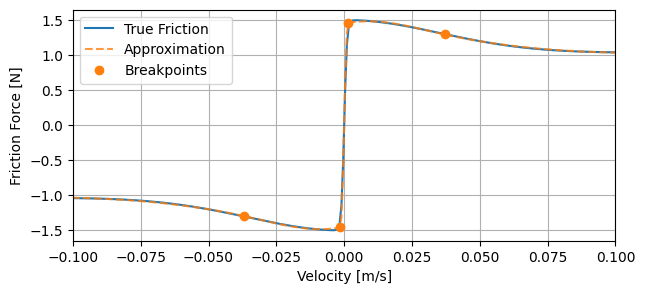

In [6]:
# Test projection of friction function onto a piecewise Hermite basis

from archimedes.experimental.approximation import FunctionSpace

# Cluster breakpoints near the origin to resolve the Stribeck effect
bkpts = np.linspace(-1, 1, 10) ** 3
space = FunctionSpace.piecewise("hermite", order=4, breakpoints=bkpts, continuity=1)
F_approx = space.project(true_friction)

v_plt = np.linspace(-1, 1, 3000)
f_plt = true_friction(v_plt)
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(v_plt, f_plt, label="True Friction")
l, = ax.plot(v_plt, F_approx(v_plt), "--", alpha=0.8, label="Approximation")
ax.plot(bkpts, F_approx(bkpts), "o", color=l.get_color(), label="Breakpoints")
ax.legend()
ax.set_xlabel('Velocity [m/s]')
ax.set_ylabel('Friction Force [N]')
ax.set_xlim([-0.1, 0.1])
ax.grid()
plt.show()

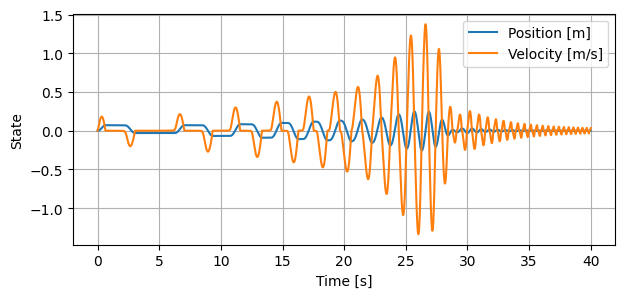

In [7]:

def ode_rhs(t, y, friction):
    u = np.interp(t, tp, u_chirp)
    x, v = y
    f = -friction(v) - k * x + u
    return np.hstack([v, f / m])

y0 = np.array([0.0, 0.0])
ys = arc.odeint(ode_rhs, [t0, tf], y0, t_eval=tp, args=(true_friction,))

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(tp, ys[0], label='Position [m]')
ax.plot(tp, ys[1], label='Velocity [m/s]')
ax.set_xlabel('Time [s]')
ax.set_ylabel('State')
ax.grid()
ax.legend()
plt.show()

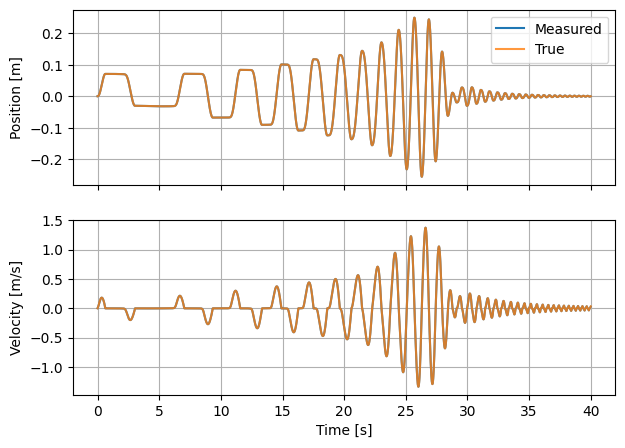

In [8]:
# Subsample to 100 Hz and add noise

ts = np.arange(t0, tf, 1e-2)
xs = np.interp(ts, tp, ys[0])
xs += 1e-6 * np.random.randn(len(xs))  # Add noise

data = arc.sysid.Timeseries(
    ts=ts,
    us=np.interp(ts, tp, u_chirp).reshape(1, -1),
    ys=xs.reshape(1, -1),
)

fig, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
ax[0].plot(ts, xs, label="Measured")
ax[0].plot(tp, ys[0], alpha=0.8, label="True")
ax[0].set_ylabel('Position [m]')
ax[0].grid()
ax[0].legend()
vs_fd = np.gradient(xs, ts)
ax[1].plot(ts, vs_fd, label="Measured")
ax[1].plot(tp, ys[1], alpha=0.8, label="True")
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Velocity [m/s]')
ax[1].grid()
plt.show()

## System ID

In [9]:
# bkpts = np.linspace(-1, 1, 30) ** 3
bkpts = np.linspace(-1, 1, 10)
space = FunctionSpace.piecewise("hermite", order=4, breakpoints=bkpts, continuity=1)
p = np.zeros_like(space.function().coefficients)
space.function(p)(np.atleast_1d(1.0))

array([0.])

In [ ]:

@arc.struct
class FrictionModel:
    """Friction model for system identification."""
    coeffs: np.ndarray
    space: FunctionSpace = arc.field(static=True)

    def __call__(self, v: float) -> float:
        """Compute the friction force for a given velocity."""
        f = self.space.function(self.coeffs)
        # FIXME: The function should handle scalars
        return f(np.atleast_1d(v)).squeeze()


# Cluster breakpoints near the origin to resolve the Stribeck effect
bkpts = np.linspace(-1, 1, 10) ** 3
# bkpts = np.linspace(-1, 1, 30)
space = FunctionSpace.piecewise("hermite", order=4, breakpoints=bkpts, continuity=1)

dt = data.ts[1] - data.ts[0]

# Dynamics model (discretized with RK4)
# @arc.discretize(dt=dt, method="rk4", n_steps=1)
def dyn(t, y, u, p):
    friction = FrictionModel(p, space)
    x, v = y
    f = -friction(v) - k * x + u
    return np.hstack([v, f / m])

# Observation model
def obs(t, y, u, p):
    return y[0]  # Observe position


nx, ny = 2, 1  # State and output dimensions

# Set up noise estimates
noise_var = 0.5 * np.var(np.diff(data.ys[0]))
R = noise_var * np.eye(ny)  # Measurement noise
Q = 1e-6 * noise_var * np.eye(nx)  # Process noise

# Extended Kalman Filter for predictions
ekf = arc.observers.ExtendedKalmanFilter(dyn, obs, Q, R)

# Estimate parameters
params_guess = np.zeros_like(space.function().coefficients)
P0 = 1e-3 * np.eye(nx)  # Initial state covariance
options = {
    "ftol": 1e-6,
}
result = arc.sysid.pem(ekf, data, params_guess, x0=np.zeros(2), P0=P0, options=options)
    
# result = arc.sysid.pem(ekf, data, params_guess, x0=np.zeros(2), P0=P0, method="bfgs")

Iteration   Total nfev       Cost       Cost reduction   Step norm    Optimality 
    0           2         8.5616e+03                                   8.14e+04  
    1           3         8.4342e+03       1.27e+02       5.89e+00     6.68e+02  
    2           4         8.3245e+03       1.10e+02       3.88e+00     9.06e+05  


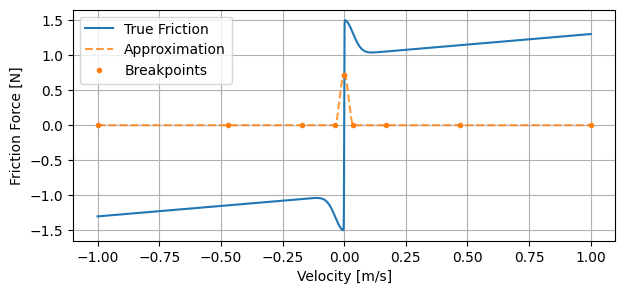

In [17]:
est_friction = space.function(result.p)

v_plt = np.linspace(-1, 1, 3000)
f_plt = true_friction(v_plt)
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(v_plt, f_plt, label="True Friction")
l, = ax.plot(v_plt, est_friction(v_plt), "--", alpha=0.8, label="Approximation")
ax.plot(bkpts, est_friction(bkpts), ".", color=l.get_color(), label="Breakpoints")
ax.legend()
ax.set_xlabel('Velocity [m/s]')
ax.set_ylabel('Friction Force [N]')
# ax.set_xlim([-0.1, 0.1])
ax.grid()
plt.show()